# Capstone 2 Bonus Analysis

This notebook answers the Appendix bonus questions for the Capstone 2 sales territory project. My assigned territories are **Maine** and **New Jersey** in the Northeast region.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_folder = Path("capstone_outputs")
output_folder.mkdir(exist_ok=True)

assigned_states = ["Maine", "New Jersey"]

## Load and prepare the data

I start by loading each CSV file. I clean the column names so they are easier to use in Python, convert the transaction date column into a datetime format, and create month and year columns for time-based analysis.

In [2]:
store_sales = pd.read_csv("StoreSales.csv")
store_detail = pd.read_csv("StoreDetail.csv")
products = pd.read_csv("Products.csv")
categories = pd.read_csv("ProductCategories.csv")
customers = pd.read_csv("customer_list.csv", sep="|")

# Clean column names
for df in [store_sales, store_detail, products, categories, customers]:
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

# Convert dates and create useful time columns
store_sales["Transaction_Date"] = pd.to_datetime(store_sales["Transaction_Date"])
store_sales["Year"] = store_sales["Transaction_Date"].dt.year
store_sales["Month"] = store_sales["Transaction_Date"].dt.to_period("M").astype(str)

store_sales.head()

,Transaction_Date,Store_ID,RewardsID,Prod_Num,Sale_Amount,Year,Month
0,2022-01-01,702,NaN,105349-M,8.00,2022,2022-01
1,2022-01-01,704,NaN,105350-T,144.00,2022,2022-01
2,2022-01-01,705,NaN,105351-M,44.00,2022,2022-01
3,2022-01-01,705,NaN,105352-M,47.61,2022,2022-01
4,2022-01-01,705,NaN,105353-A,20.36,2022,2022-01


## Create merged datasets

Many bonus questions require data from more than one CSV file. I create a full merged dataset that connects sales transactions with store details, product information, product category names, and customer rewards information.

In [3]:
sales_store = store_sales.merge(store_detail, on="Store_ID", how="left")

sales_product = sales_store.merge(products, on="Prod_Num", how="left")

full_sales = sales_product.merge(
    categories[["CategoryID", "Category", "SubcategoryID", "Subcategory"]].drop_duplicates(),
    on=["CategoryID", "SubcategoryID"],
    how="left"
)

full_sales = full_sales.merge(
    customers,
    left_on="RewardsID",
    right_on="cust_id",
    how="left"
)

territory_sales = full_sales[full_sales["State"].isin(assigned_states)].copy()

full_sales.head()

,Transaction_Date,Store_ID,RewardsID,Prod_Num,Sale_Amount,Year,Month,Store_Location,State,Territory_Manager,...,SubcategoryID,Category,Subcategory,cust_id,date,time,name,email,phone,sms_opt_out
0,2022-01-01,702,NaN,105349-M,8.00,2022,2022-01,Berthoud,Colorado,Jim Heck,...,130-off,Apparel and Merchandise,Office and Study Supplies,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,704,NaN,105350-T,144.00,2022,2022-01,Castle Rock,Colorado,Jim Heck,...,100-bus,Textbooks,Business & Economics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,705,NaN,105351-M,44.00,2022,2022-01,Denver,Colorado,Jim Heck,...,130-clo,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,705,NaN,105352-M,47.61,2022,2022-01,Denver,Colorado,Jim Heck,...,130-tec,Apparel and Merchandise,Technology Accessories,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,705,NaN,105353-A,20.36,2022,2022-01,Denver,Colorado,Jim Heck,...,115-ske,Art Supplies,Sketchbooks and Paper,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. January 2024 transactions sorted by sale amount

This question asks for all transactions from January 2024, sorted from highest sale amount to lowest. I also filter that result to find only transactions greater than $500.

In [4]:
january_2024 = full_sales[
    (full_sales["Transaction_Date"].dt.year == 2024) &
    (full_sales["Transaction_Date"].dt.month == 1)
].sort_values("Sale_Amount", ascending=False)

january_2024_over_500 = january_2024[january_2024["Sale_Amount"] > 500]

january_2024.to_csv(output_folder / "bonus_01_january_2024_transactions.csv", index=False)
january_2024_over_500.to_csv(output_folder / "bonus_01_january_2024_transactions_over_500.csv", index=False)

january_2024_over_500

,Transaction_Date,Store_ID,RewardsID,Prod_Num,Sale_Amount,Year,Month,Store_Location,State,Territory_Manager,...,SubcategoryID,Category,Subcategory,cust_id,date,time,name,email,phone,sms_opt_out
137643,2024-01-01,726,NaN,105341-IT,1763.7,2024,2024-01,Orlando,Florida,Lana Ilana,...,120-lap,Technology & Accessories,Laptops,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143377,2024-01-27,701,NaN,105341-IT,1763.7,2024,2024-01,Aurora,Colorado,Jim Heck,...,120-lap,Technology & Accessories,Laptops,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143437,2024-01-27,736,NaN,105341-IT,1763.7,2024,2024-01,North Harford,Maryland,Shruti Reddy,...,120-lap,Technology & Accessories,Laptops,NaN,NaN,NaN,NaN,NaN,NaN,NaN
139838,2024-01-10,823,337.0,105341-IT,1763.7,2024,2024-01,South Portland,Maine,Erbayne Middleton,...,120-lap,Technology & Accessories,Laptops,337.0,2024-01-21,11:35:20,Sayid Jarrah,sayid@dharma.initiative,808-555-1406,N
139674,2024-01-09,872,NaN,105341-IT,1763.7,2024,2024-01,Waterbury,Connecticut,Ellen Lemon,...,120-lap,Technology & Accessories,Laptops,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138661,2024-01-05,825,NaN,105262-IT,603.5,2024,2024-01,Bayonne,New Jersey,Miami Vue,...,120-tab,Technology & Accessories,Tablets,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143945,2024-01-29,815,NaN,105262-IT,603.5,2024,2024-01,Quincy,Massachusetts,Bo Heap,...,120-tab,Technology & Accessories,Tablets,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138474,2024-01-04,851,NaN,105262-IT,603.5,2024,2024-01,Queens,New York,See Ellefson,...,120-tab,Technology & Accessories,Tablets,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140944,2024-01-15,847,NaN,105262-IT,603.5,2024,2024-01,Rochester,New York,See Ellefson,...,120-tab,Technology & Accessories,Tablets,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Products whose product number begins with 10525

This question asks me to search product numbers that start with `10525`. I convert the product number to text, use `.str.startswith()`, and display the category and subcategory for each matching product.

In [5]:
products_with_categories = products.merge(
    categories[["CategoryID", "Category", "SubcategoryID", "Subcategory"]].drop_duplicates(),
    on=["CategoryID", "SubcategoryID"],
    how="left"
)

products_10525 = products_with_categories[
    products_with_categories["Prod_Num"].astype(str).str.startswith("10525")
]

products_10525.to_csv(output_folder / "bonus_02_products_beginning_10525.csv", index=False)

products_10525

,Prod_Num,Product,CategoryID,SubcategoryID,Category,Subcategory
2,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,Tablets
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab,Technology & Accessories,Tablets
4,105252-IT,Microsoft Surface Pro 9,120,120-tab,Technology & Accessories,Tablets
5,105253-IT,"Apple iPad Pro (12.9-inch, M2)",120,120-tab,Technology & Accessories,Tablets
6,105254-IT,Chuwi HiPad Max,120,120-tab,Technology & Accessories,Tablets
7,105255-IT,Lenovo Yoga Smart Tab,120,120-tab,Technology & Accessories,Tablets
8,105256-IT,ASUS Vivobook 13 Slate OLED,120,120-tab,Technology & Accessories,Tablets
9,105257-IT,Samsung Galaxy Tab S9 Ultra,120,120-tab,Technology & Accessories,Tablets
10,105258-IT,Apple iPad Air (10.9-inch),120,120-tab,Technology & Accessories,Tablets
11,105259-IT,Teclast T40 Pro,120,120-tab,Technology & Accessories,Tablets


## 3. Stores in my territories with transactions over $1,000

This question focuses only on Maine and New Jersey. I filter for transactions over $1,000, then group by store to count how many large transactions each store had.

In [6]:
territory_over_1000 = territory_sales[territory_sales["Sale_Amount"] > 1000]

stores_over_1000 = territory_over_1000.groupby(
    ["State", "Store_ID", "Store_Location"],
    as_index=False
).size()

stores_over_1000 = stores_over_1000.rename(columns={"size": "Transactions_Over_1000"})
stores_over_1000 = stores_over_1000.sort_values("Transactions_Over_1000", ascending=False)

stores_over_1000.to_csv(output_folder / "bonus_03_stores_transactions_over_1000.csv", index=False)

stores_over_1000

,State,Store_ID,Store_Location,Transactions_Over_1000
17,New Jersey,835,Newark,177
20,New Jersey,838,Trenton,163
6,New Jersey,824,Atlantic City,100
5,Maine,823,South Portland,97
12,New Jersey,830,Hoboken,96
0,Maine,818,Bangor,93
2,Maine,820,Kennebunkport,93
21,New Jersey,839,Vineland,86
4,Maine,822,Orono,85
15,New Jersey,833,Morristown,85


## 4. Total revenue, average transaction amount, and standard deviation

This question looks at all in-store transactions in the dataset. I calculate total revenue, the average transaction amount, and the standard deviation of sale amounts.

In [7]:
total_revenue = full_sales["Sale_Amount"].sum()
average_transaction = full_sales["Sale_Amount"].mean()
std_transaction = full_sales["Sale_Amount"].std()

bonus_04_summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Average Transaction Amount", "Standard Deviation"],
    "Value": [total_revenue, average_transaction, std_transaction]
})

bonus_04_summary.to_csv(output_folder / "bonus_04_revenue_average_std.csv", index=False)

bonus_04_summary

,Metric,Value
0,Total Revenue,4.572877e+07
1,Average Transaction Amount,1.316451e+02
2,Standard Deviation,2.754541e+02


## 5. Stores above the average store revenue

This question asks which stores had total revenue above the average store revenue across the full dataset. I calculate total revenue per store, use `np.mean()` to find the average, then filter stores above that average.

In [8]:
store_revenue_full = full_sales.groupby(
    ["Store_ID", "Store_Location", "State"],
    as_index=False
)["Sale_Amount"].sum()

store_revenue_full = store_revenue_full.rename(columns={"Sale_Amount": "Total_Store_Revenue"})

average_store_revenue = np.mean(store_revenue_full["Total_Store_Revenue"])

stores_above_average = store_revenue_full[
    store_revenue_full["Total_Store_Revenue"] > average_store_revenue
].sort_values("Total_Store_Revenue", ascending=False)

stores_above_average.to_csv(output_folder / "bonus_05_stores_above_average_revenue.csv", index=False)

stores_above_average

,Store_ID,Store_Location,State,Total_Store_Revenue
35,736,North Harford,Maryland,8772702.75
4,705,Denver,Colorado,925684.89
8,709,Greeley,Colorado,646301.23
104,905,Beaumont,Texas,643579.72
73,835,Newark,New Jersey,627786.37
88,850,New York,New York,626884.12
23,724,Miami,Florida,623988.83
85,847,Rochester,New York,611694.60
55,817,Worcester,Massachusetts,607873.78
76,838,Trenton,New Jersey,602254.10


## 6. Total revenue by product category and category with most transactions

This question asks for category revenue across all territories and also asks which category has the most individual transactions. I group by category and calculate both total revenue and transaction count.

In [9]:
category_summary_full = full_sales.groupby(
    "Category",
    as_index=False
).agg(
    Total_Revenue=("Sale_Amount", "sum"),
    Total_Transactions=("Sale_Amount", "count")
)

category_summary_full = category_summary_full.sort_values("Total_Revenue", ascending=False)

most_transactions_category = category_summary_full.sort_values(
    "Total_Transactions",
    ascending=False
).head(1)

category_summary_full.to_csv(output_folder / "bonus_06_category_revenue_and_transactions.csv", index=False)

category_summary_full

,Category,Total_Revenue,Total_Transactions
4,Technology & Accessories,31891406.58,68344
5,Textbooks,7961357.21,45924
0,Apparel and Merchandise,2043382.60,63346
1,Art Supplies,1938358.84,62028
2,Books (General),1070718.51,35196
3,Stationery and Supplies,702088.52,69176


In [10]:
most_transactions_category

,Category,Total_Revenue,Total_Transactions
3,Stationery and Supplies,702088.52,69176


## 7. Top 10 best-selling individual products by total revenue

This question asks for the individual products that generated the most revenue across the full dataset. I group by product number and product name, total the revenue, and return the top 10.

In [11]:
top_10_products = full_sales.groupby(
    ["Prod_Num", "Product", "Category", "Subcategory"],
    as_index=False
).agg(
    Total_Revenue=("Sale_Amount", "sum"),
    Total_Transactions=("Sale_Amount", "count")
)

top_10_products = top_10_products.sort_values("Total_Revenue", ascending=False).head(10)

top_10_products.to_csv(output_folder / "bonus_07_top_10_products_by_revenue.csv", index=False)

top_10_products

,Prod_Num,Product,Category,Subcategory,Total_Revenue,Total_Transactions
93,105341-IT,MSI Creator Z16,Technology & Accessories,Laptops,1199316.00,680
77,105325-IT,"Apple MacBook Pro (M2, 14-inch)",Technology & Accessories,Laptops,1082151.00,630
78,105326-IT,"Apple MacBook Air (M2, 13-inch)",Technology & Accessories,Laptops,1003136.80,584
89,105337-IT,HP Pavilion 14,Technology & Accessories,Laptops,913919.76,702
85,105333-IT,ASUS VivoBook S15,Technology & Accessories,Laptops,900524.00,697
86,105334-IT,Samsung Galaxy Book Pro,Technology & Accessories,Laptops,890257.12,698
76,105324-IT,Lenovo IdeaPad Flex 5,Technology & Accessories,Laptops,877535.40,678
82,105330-IT,LG Gram 17,Technology & Accessories,Laptops,876792.28,637
84,105332-IT,HP Spectre x360,Technology & Accessories,Laptops,874421.04,699
83,105331-IT,Acer Chromebook Spin 713,Technology & Accessories,Laptops,872358.20,674


## 8. Territory transactions with date, sale amount, city, state, and territory manager

This question requires merging sales with store details. Since I already created the merged table, I select the required columns for Maine and New Jersey.

In [12]:
territory_transaction_details = territory_sales[
    ["Transaction_Date", "Sale_Amount", "Store_Location", "State", "Territory_Manager"]
].sort_values("Transaction_Date")

territory_transaction_details.to_csv(output_folder / "bonus_08_territory_transaction_details.csv", index=False)

territory_transaction_details.head(20)

,Transaction_Date,Sale_Amount,Store_Location,State,Territory_Manager
98,2022-01-01,28.88,Bangor,Maine,Erbayne Middleton
119,2022-01-01,178.60,Trenton,New Jersey,Miami Vue
118,2022-01-01,2.40,Passaic,New Jersey,Miami Vue
117,2022-01-01,9.95,Newark,New Jersey,Miami Vue
116,2022-01-01,47.61,Newark,New Jersey,Miami Vue
115,2022-01-01,9.09,Newark,New Jersey,Miami Vue
113,2022-01-01,312.70,Newark,New Jersey,Miami Vue
112,2022-01-01,7.85,New Brunswick,New Jersey,Miami Vue
111,2022-01-01,57.70,Morristown,New Jersey,Miami Vue
110,2022-01-01,48.00,Morristown,New Jersey,Miami Vue


## 9. Total revenue by region across the full dataset

This question asks which region generates the most revenue. I group the full merged dataset by region and sum the sale amounts.

In [13]:
region_revenue = full_sales.groupby(
    "Region",
    as_index=False
)["Sale_Amount"].sum()

region_revenue = region_revenue.rename(columns={"Sale_Amount": "Total_Revenue"})
region_revenue = region_revenue.sort_values("Total_Revenue", ascending=False)

top_region = region_revenue.head(1)

region_revenue.to_csv(output_folder / "bonus_09_revenue_by_region.csv", index=False)

region_revenue

,Region,Total_Revenue
1,Northeast,24428353.42
2,South,8058888.51
0,East,6775711.02
3,West,6465821.91


In [14]:
top_region

,Region,Total_Revenue
1,Northeast,24428353.42


## 10. Revenue and transactions by product subcategory in my territories

This question focuses on Maine and New Jersey. I group the territory data by subcategory and calculate total revenue and number of transactions.

In [15]:
subcategory_summary = territory_sales.groupby(
    ["State", "Subcategory"],
    as_index=False
).agg(
    Total_Revenue=("Sale_Amount", "sum"),
    Number_of_Transactions=("Sale_Amount", "count")
)

subcategory_summary = subcategory_summary.sort_values(
    ["State", "Total_Revenue"],
    ascending=[True, False]
)

subcategory_summary.to_csv(output_folder / "bonus_10_subcategory_summary_territories.csv", index=False)

subcategory_summary

,State,Subcategory,Total_Revenue,Number_of_Transactions
24,Maine,Laptops,707578.47,538
48,Maine,Tablets,352681.23,468
45,Maine,Software Download,154522.81,521
4,Maine,Business & Economics,55744.92,346
5,Maine,Calculators,53967.67,156
...,...,...,...,...
90,New Jersey,Pencils and Erasers,4907.00,803
85,New Jersey,Organization Supplies,4533.22,547
91,New Jersey,Planners and Calendars,3428.80,243
92,New Jersey,Reference Materials,3398.80,116


## 11. Rewards members in my territories and average transaction value

This question compares rewards customers to non-rewards customers. I create a new column that labels each transaction as Rewards Member or Non-Rewards Customer, then compare average transaction value for both groups.

In [16]:
territory_sales["Customer_Type"] = np.where(
    territory_sales["RewardsID"].notna(),
    "Rewards Member",
    "Non-Rewards Customer"
)

rewards_members_in_territories = territory_sales[
    territory_sales["RewardsID"].notna()
][["RewardsID", "name", "email", "State"]].drop_duplicates()

avg_transaction_by_customer_type = territory_sales.groupby(
    "Customer_Type",
    as_index=False
).agg(
    Average_Transaction_Value=("Sale_Amount", "mean"),
    Number_of_Transactions=("Sale_Amount", "count")
)

rewards_members_in_territories.to_csv(output_folder / "bonus_11_rewards_members_in_territories.csv", index=False)
avg_transaction_by_customer_type.to_csv(output_folder / "bonus_11_rewards_vs_non_rewards_average.csv", index=False)

avg_transaction_by_customer_type

,Customer_Type,Average_Transaction_Value,Number_of_Transactions
0,Non-Rewards Customer,132.429629,47861
1,Rewards Member,139.948192,5520


In [17]:
rewards_members_in_territories.head(20)

,RewardsID,name,email,State
99,507.0,Plankton,plankton@bikinibottom.net,Maine
101,491.0,Harry Crane,harry@sterlingcooper.com,Maine
102,280.0,Cal Abar,cal@keenecounty.police,Maine
103,104.0,Helen M.,helen@lawndale.high,Maine
105,513.0,Ferb Fletcher,ferb@danvillekids.com,New Jersey
107,122.0,Henrietta Pussycat,meow@neighborhood.org,New Jersey
262,515.0,Isabella G.,isabella@danvillekids.com,New Jersey
266,214.0,Nicky B.,nicky@banksresidence.la,New Jersey
432,67.0,Britta P.,britta@greendale.edu,New Jersey
448,284.0,Red Scare,redscare@keenecounty.police,New Jersey


## 12. Top 10 rewards members by total spend across the full dataset

This question looks at rewards members across the full dataset. I remove transactions without a rewards ID, group by customer, total their spending, count transactions, and show the top 10.

In [18]:
top_10_rewards_members = full_sales.dropna(subset=["RewardsID"]).groupby(
    ["RewardsID", "name", "email"],
    as_index=False
).agg(
    Total_Spend=("Sale_Amount", "sum"),
    Number_of_Transactions=("Sale_Amount", "count")
)

top_10_rewards_members = top_10_rewards_members.sort_values(
    "Total_Spend",
    ascending=False
).head(10)

top_10_rewards_members.to_csv(output_folder / "bonus_12_top_10_rewards_members.csv", index=False)

top_10_rewards_members

,RewardsID,name,email,Total_Spend,Number_of_Transactions
244,245.0,Gloria Mendoza,gloria@litchfield.pen,17534.76,79
73,74.0,Ben Chang,chang@greendale.edu,17494.39,86
179,180.0,Cole Brown,cole@wzhup.det,17440.65,93
46,47.0,Stanley H.,stanley@dundermifflin.com,16532.80,77
374,375.0,C.J. Cregg,cj@westwing.gov,16520.45,85
279,280.0,Cal Abar,cal@keenecounty.police,16453.48,83
241,242.0,Lorna Morello,lorna@litchfield.pen,15984.11,77
408,409.0,Gerri Kellman,gerri@waystarroyco.com,15959.27,85
98,99.0,Trent Lane,trent@lawndale.high,15847.67,82
399,400.0,K. McClanahan,katherine@goldengirls.house,15625.56,76


## 13. Year-over-year revenue for my territories

This question compares revenue between years for Maine and New Jersey. I group by state and year, then calculate the year-over-year change and percentage change.

In [19]:
yoy_revenue = territory_sales.groupby(
    ["State", "Year"],
    as_index=False
)["Sale_Amount"].sum()

yoy_revenue = yoy_revenue.rename(columns={"Sale_Amount": "Total_Revenue"})
yoy_revenue = yoy_revenue.sort_values(["State", "Year"])

yoy_revenue["Revenue_Change"] = yoy_revenue.groupby("State")["Total_Revenue"].diff()
yoy_revenue["Percent_Change"] = yoy_revenue.groupby("State")["Total_Revenue"].pct_change() * 100

yoy_revenue["Trend"] = np.where(
    yoy_revenue["Revenue_Change"] > 0,
    "Trending Up",
    np.where(yoy_revenue["Revenue_Change"] < 0, "Trending Down", "No Prior Year")
)

yoy_revenue.to_csv(output_folder / "bonus_13_year_over_year_revenue.csv", index=False)

yoy_revenue

,State,Year,Total_Revenue,Revenue_Change,Percent_Change,Trend
0,Maine,2022,281388.10,NaN,NaN,No Prior Year
1,Maine,2023,454030.82,172642.72,61.353952,Trending Up
2,Maine,2024,455603.86,1573.04,0.346461,Trending Up
3,Maine,2025,701160.45,245556.59,53.896951,Trending Up
4,New Jersey,2022,885227.00,NaN,NaN,No Prior Year
5,New Jersey,2023,1221944.54,336717.54,38.037423,Trending Up
6,New Jersey,2024,1224584.68,2640.14,0.216061,Trending Up
7,New Jersey,2025,1886789.06,662204.38,54.075834,Trending Up


## 14. Best and worst month for each territory

This question asks for the single best and single worst month for each territory. I calculate monthly revenue by state, then find the highest and lowest month for each state.

In [20]:
monthly_territory_revenue = territory_sales.groupby(
    ["State", "Month"],
    as_index=False
)["Sale_Amount"].sum()

monthly_territory_revenue = monthly_territory_revenue.rename(
    columns={"Sale_Amount": "Monthly_Revenue"}
)

best_months = monthly_territory_revenue.loc[
    monthly_territory_revenue.groupby("State")["Monthly_Revenue"].idxmax()
].copy()

best_months["Month_Type"] = "Best Month"

worst_months = monthly_territory_revenue.loc[
    monthly_territory_revenue.groupby("State")["Monthly_Revenue"].idxmin()
].copy()

worst_months["Month_Type"] = "Worst Month"

best_worst_months = pd.concat([best_months, worst_months]).sort_values(["State", "Month_Type"])

best_worst_months.to_csv(output_folder / "bonus_14_best_and_worst_months.csv", index=False)

best_worst_months

,State,Month,Monthly_Revenue,Month_Type
45,Maine,2025-10,94192.76,Best Month
0,Maine,2022-01,15837.31,Worst Month
93,New Jersey,2025-10,252453.51,Best Month
49,New Jersey,2022-02,63816.90,Worst Month


## 15. Linear regression trend line for monthly revenue

This question asks whether each territory is trending up or down overall. I use `np.polyfit()` to fit a straight trend line to monthly revenue for each territory. A positive slope means the territory is trending up, while a negative slope means it is trending down.

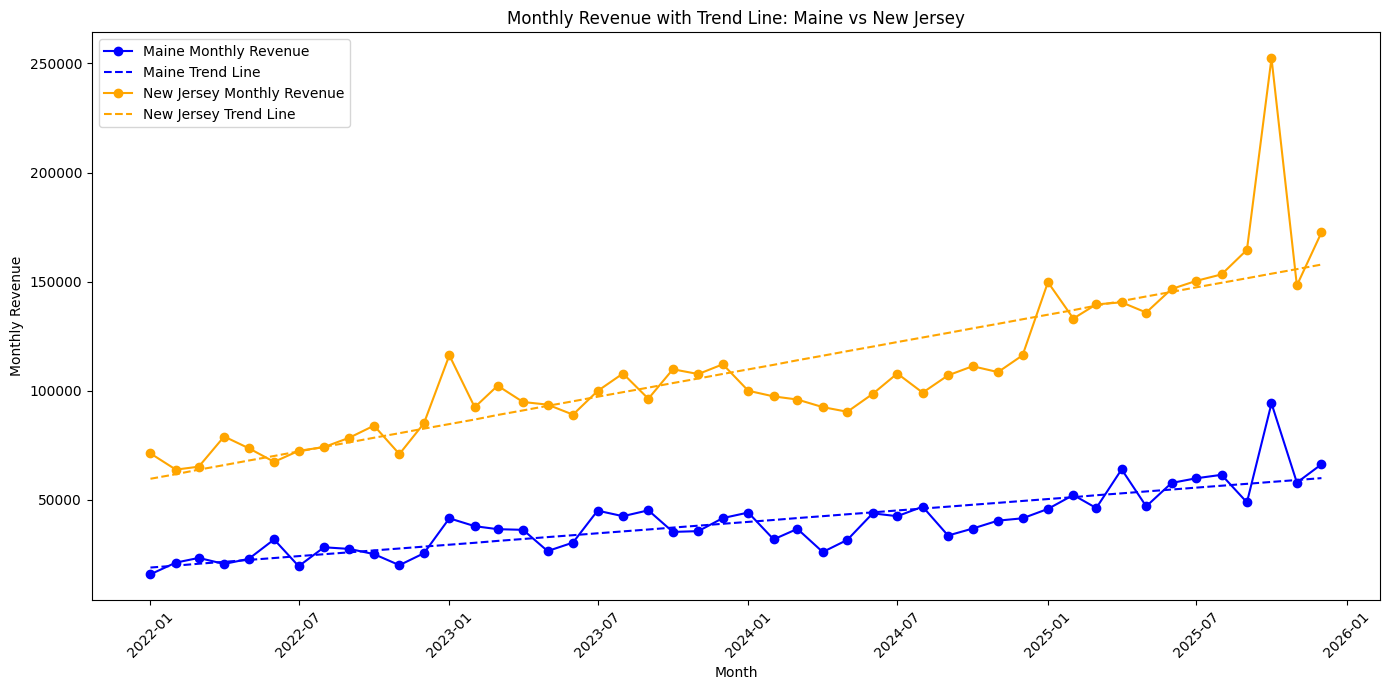

,State,Slope,Trend_Direction
0,Maine,872.171482,Trending Up
1,New Jersey,2089.318976,Trending Up


In [21]:
monthly_trend = monthly_territory_revenue.copy()
monthly_trend["Month_Date"] = pd.to_datetime(monthly_trend["Month"] + "-01")
monthly_trend = monthly_trend.sort_values(["State", "Month_Date"])

trend_results = []

plt.figure(figsize=(14, 7))

state_colors = {
    "Maine": "blue",
    "New Jersey": "orange"
}

for state in assigned_states:
    state_data = monthly_trend[monthly_trend["State"] == state].copy()
    state_data["Month_Number"] = range(len(state_data))

    x = state_data["Month_Number"]
    y = state_data["Monthly_Revenue"]

    slope, intercept = np.polyfit(x, y, 1)
    trend_line = slope * x + intercept

    trend_direction = "Trending Up" if slope > 0 else "Trending Down"

    trend_results.append({
        "State": state,
        "Slope": slope,
        "Trend_Direction": trend_direction
    })

    plt.plot(
        state_data["Month_Date"],
        y,
        marker="o",
        color=state_colors[state],
        label=f"{state} Monthly Revenue"
    )

    plt.plot(
        state_data["Month_Date"],
        trend_line,
        linestyle="--",
        color=state_colors[state],
        label=f"{state} Trend Line"
    )

trend_results = pd.DataFrame(trend_results)
trend_results.to_csv(output_folder / "bonus_15_linear_regression_trend_results.csv", index=False)

plt.title("Monthly Revenue with Trend Line: Maine vs New Jersey")
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_folder / "bonus_15_monthly_revenue_trend_line.png")
plt.show()

trend_results

## Bonus analysis conclusion

This bonus analysis extends the main Capstone 2 project by answering additional questions about filtering, sorting, aggregation, merging, grouping, customer behavior, and revenue trends. These results can support the final recommendation by showing which stores, products, regions, customers, and months performed strongest across the dataset.